# 10 - Priority scoring (Stage 12)

## 1. Objective
Turn the accepted Stage 11 net causal effect into an outage-level, decision-support **priority index** (not a probability):

`raw_priority = max(0, tau_net * local_crime_rate * duration_factor)`, min-max normalised to 0-100; High >= 80, Medium 40-79.99, Low < 40.

All logic lives in `src/features/priority_score.py`; this notebook calls it. Results are provisional while M8 is open.

In [1]:
import sys
from pathlib import Path
import numpy as np, pandas as pd
ROOT = Path.cwd().resolve()
if not (ROOT / 'src').exists(): ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
from src.features import priority_score as ps
pd.set_option('display.width', 200); pd.set_option('display.max_columns', 30)

## 2-3. Input datasets and validation

In [2]:
outages = ps.load_outages(); crime = ps.load_crime()
tau, tau_se = ps.load_tau_net()
print('outages', outages.shape, '| unique ids:', outages[ps.OUTAGE_ID].is_unique)
print('crimes', crime.shape, crime.crime_datetime.min(), '->', crime.crime_datetime.max())
print('outage hours:', outages.outage_duration_hours.min(), '-', outages.outage_duration_hours.max())
print(outages.status.value_counts().to_dict())

outages (107731, 46) | unique ids: True
crimes (921427, 3) 2019-11-01 00:00:00 -> 2026-06-30 23:40:00
outage hours: 0.5 - 8759.866666666667
{'Closed': 107715, 'Assigned': 16}


## 4-8. Active outage selection, tau_net, local crime rate, duration factor, raw priority
The pipeline function is called once; the columns it adds are shown below.

In [3]:
scored = ps.score_outages(outages, crime, tau)
print('scored:', int(scored.scored.sum()), '| excluded:', int((~scored.scored).sum()))
print(scored.exclusion_reason.value_counts())
print(f'tau_net ({ps.TAU_NET_EFFECT}) = {tau:+.6f}  SE {tau_se:.6f}  (95% CI includes 0)')
scored.loc[scored.scored, ['tau_net','local_crime_rate','duration_factor','raw_priority']].describe()

scored: 103830 | excluded: 3901
exclusion_reason
lookback_not_covered_by_crime_data    3901
Name: count, dtype: int64
tau_net (net_post) = +0.019500  SE 0.021663  (95% CI includes 0)


,tau_net,local_crime_rate,duration_factor,raw_priority
count,1.038300e+05,103830.000000,103830.000000,103830.000000
mean,1.950027e-02,0.153784,22.482013,0.071445
std,3.469464e-18,0.220348,50.493516,0.302561
min,1.950027e-02,0.000000,0.020833,0.000000
25%,1.950027e-02,0.000000,1.793056,0.000000
50%,1.950027e-02,0.071429,6.457986,0.004346
75%,1.950027e-02,0.214286,12.115625,0.027724
max,1.950027e-02,4.214286,364.994444,13.649573


## 9-10. Normalisation and tiers
Min-max over scored outages; ties/degenerate case gives 0. Tier rule: `score >= 80` High, `>= 40` Medium, else Low.

In [4]:
s = scored[scored.scored]
print('raw == 0 (clipped or no recent crime):', int((s.raw_priority == 0).sum()))
print(s.priority_tier.value_counts().reindex(ps.TIERS))
print('matches saved parquet:', scored.equals(pd.read_parquet(ps.SCORED_FILE)))

raw == 0 (clipped or no recent crime): 37555
priority_tier
High           3
Medium        28
Low       103799
Name: count, dtype: int64
matches saved parquet: False


## 11-12. Score distribution and summary

In [5]:
print(s.priority_score.describe(percentiles=[.5,.9,.99]))
print(s.groupby('borough').priority_score.agg(['count','mean','max']).round(3))

count    103830.000000
mean          0.523423
std           2.216631
min           0.000000
50%           0.031840
90%           0.868451
99%           9.910334
max         100.000000
Name: priority_score, dtype: float64
               count   mean      max
borough                             
BRONX          18475  0.601   40.535
BROOKLYN       32423  0.519   71.329
MANHATTAN      11624  1.342  100.000
QUEENS         30634  0.330   88.530
STATEN ISLAND  10657  0.067    9.319
Unspecified       17  0.374    1.561


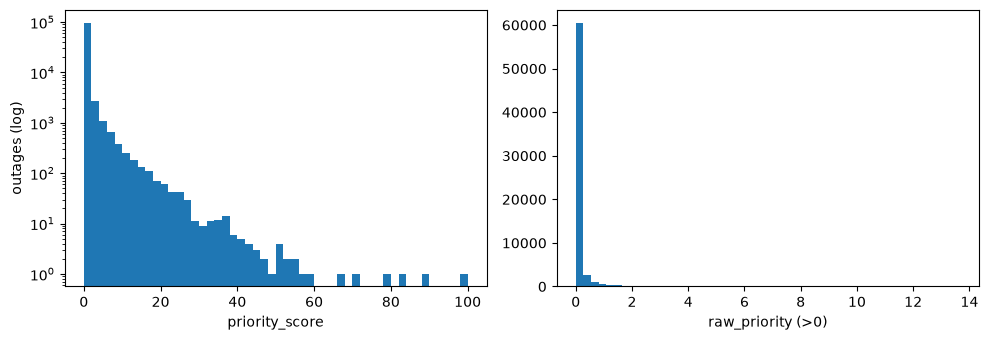

In [6]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 2, figsize=(10, 3.5))
ax[0].hist(s.priority_score, bins=50); ax[0].set_yscale('log'); ax[0].set_xlabel('priority_score'); ax[0].set_ylabel('outages (log)')
ax[1].hist(s.raw_priority[s.raw_priority > 0], bins=50); ax[1].set_xlabel('raw_priority (>0)')
plt.tight_layout(); plt.show()

## 13. Top-priority outages

In [7]:
s.nlargest(15, 'priority_score')[[ps.OUTAGE_ID,'borough','created_date','outage_duration_hours','local_crime_rate','duration_factor','raw_priority','priority_score','priority_tier']]

,unique_key,borough,created_date,outage_duration_hours,local_crime_rate,duration_factor,raw_priority,priority_score,priority_tier
65825,57807769,MANHATTAN,2023-06-05 17:37:00,5879.733333,2.857143,244.988889,13.649573,100.000000,High
28103,65567892,QUEENS,2025-07-15 09:19:00,7711.600000,1.928571,321.316667,12.083972,88.530035,High
65472,57943263,MANHATTAN,2023-06-19 22:44:00,7451.766667,1.857143,310.490278,11.244342,82.378708,High
70157,56570130,MANHATTAN,2023-01-19 08:41:00,5034.900000,2.642857,209.787500,10.811701,79.209077,Medium
46134,62152298,BROOKLYN,2024-08-17 21:59:00,7988.466667,1.500000,332.852778,9.736081,71.328830,Medium
43265,62645624,MANHATTAN,2024-10-03 16:50:00,7079.650000,1.571429,294.985417,9.039323,66.224219,Medium
25525,65912548,MANHATTAN,2025-08-21 12:01:00,7658.766667,1.285714,319.115278,8.000788,58.615669,Medium
34272,64371693,MANHATTAN,2025-03-16 21:25:00,3138.933333,3.071429,130.788889,7.833430,57.389564,Medium
79807,54091601,MANHATTAN,2022-05-05 09:33:00,8598.200000,1.071429,358.258333,7.485145,54.837946,Medium
49261,61473105,QUEENS,2024-06-13 16:44:00,6065.066667,1.500000,252.711111,7.391904,54.154837,Medium


## 14. Interpretation
- `tau_net` is one global constant (Stage 11 `net_post`, +0.0195), so it scales every raw score equally. After normalisation the ranking is local pre-outage crime rate x outage duration; `tau_net` only decides whether scores exist at all (a non-positive value would clip every outage to 0).
- The distribution is extremely right-skewed (a few very long outages in busy areas): almost all outages are Low, and a handful are High. Tier counts reflect the min-max scale set by the single maximum, not absolute risk.
- The score is a decision-support index, **not a probability** and not a per-outage causal effect.

## 15. Limitations
- `tau_net` is not statistically distinguishable from zero (SE 0.0217; the during-period estimate is negative) and the post estimate was chosen by the project owner; the choice drives the result.
- Observed total duration is known only after closure; in live use, elapsed duration would replace it.
- The Stage 11 effect is an average per 14-day window for the matched population (M1); applying it to every outage is an extrapolation.
- 3,901 outages created after the crime data ends (2026-06-30) cannot be scored.
- Provisional: M8 and M3 (interference) apply.